# 8 — Neutrons (and gammas) from the parked reactor: how much shielding?

The feasibility question behind notebooks 5–7: a $10$ MW core at $50$ m emits
$\sim2\times10^{17}$ leaking neutrons/s and $\sim5\times10^{18}$ core gammas/s. What does
it take for this not to spoil JUNO's single-hit physics?

**Method** (`reactor/shielding.py`), three factors:

1. **Source**: fission rate $P/E_f$, $\bar\nu = 2.43$ n/fission on the U235 **Watt
   spectrum** $\chi(E)\propto e^{-E/a}\sinh\sqrt{bE}$ ($\langle E\rangle \approx 2$ MeV),
   with a deliberately pessimistic $25\%$ core leakage; gammas from the FRJ-1 power law of
   notebook 7.
2. **Transport**: *removal cross-section* theory,
   $T = \exp(-\sum_i \Sigma_{R,i} d_i)$ — valid when the shield is backed by hydrogenous
   material, which is always true here because **every line from the reactor to the LS
   crosses $\gtrsim4$ m of JUNO's own water pool**. Spectral hardening of the deep flux is
   modelled by scaling the hydrogen removal with the $n$–$p$ cross section; scatter
   build-up is folded as a flat $\times5$. Gammas use NIST attenuation anchors.
3. **Requirement**: every neutron entering the LS makes $\geq1$ single-hit event (its
   $2.2$ MeV capture gamma sits inside every analysis window) — count them 1:1,
   conservative. Targets: $<10$/day (negligible against the $\sim600$/day IBD singles and
   $\sim160$/day solar E$\nu$ES of notebook 5) and $<0.1$/day (negligible against
   everything).

**Stated caveats**: removal theory is an estimate, not transport — duct streaming, skyshine
off the cavern, rock-capture gammas and activation are Monte Carlo territory; the $\times5$
build-up factor is a stand-in; capture gammas born in the pool's outer metre are
self-shielded by the remaining water ($e^{-\sim14}$) and neglected.

quantity                       module  reference
------------------------------------------------
Watt normalisation             1.0000  1.0000   
Watt <E> [MeV]                 2.0309  2.0308   
Sigma_R(water, 2 MeV) [1/cm]   0.1010  0.1030   
Sigma_R(steel, 2 MeV) [1/cm]   0.1681  0.1680   
gamma mu(water, 1 MeV) [1/cm]  0.0707  0.0707   
gamma mu(lead, 3 MeV) [1/cm]   0.4778  0.4780   


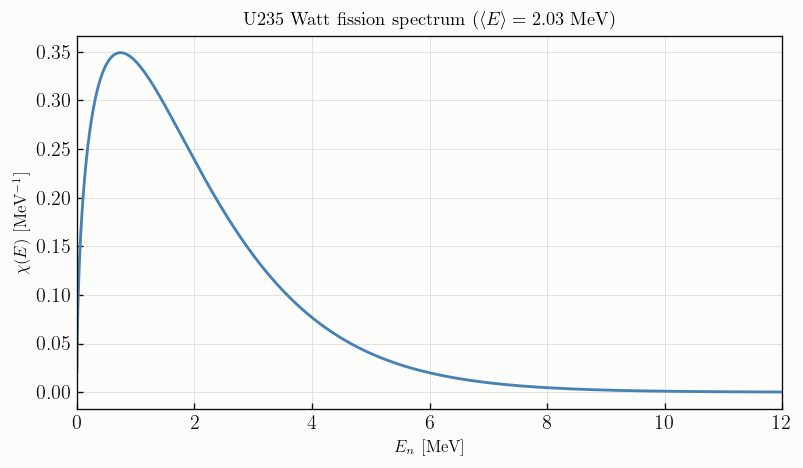

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from reactor import plotting as pl
from reactor.shielding import (ShieldingEstimate, watt_spectrum,
                               sigma_removal, gamma_mu)

pl.use_style()

e = np.linspace(1e-3, 20, 6000)
w = watt_spectrum(e)
rows = [
    ["Watt normalisation", float(np.trapezoid(w, e)), 1.0],
    ["Watt <E> [MeV]", float(np.trapezoid(e*w, e)), 0.988*(1.5+0.988*2.249/4)],
    ["Sigma_R(water, 2 MeV) [1/cm]",
     float(sigma_removal('water', [2.0])[0]), 0.103],
    ["Sigma_R(steel, 2 MeV) [1/cm]",
     float(sigma_removal('steel', [2.0])[0]), 0.168],
    ["gamma mu(water, 1 MeV) [1/cm]", float(gamma_mu('water', [1.0])[0]), 0.0707],
    ["gamma mu(lead, 3 MeV) [1/cm]", float(gamma_mu('lead', [3.0])[0]), 0.478],
]
print(pl.table(rows, ["quantity", "module", "reference"], floatfmt="{:.4f}"))

fig, ax = plt.subplots(figsize=(6.8, 4.0))
ax.plot(e, w, color=pl.BLUE, lw=1.7)
ax.set_xlim(0, 12)
ax.set_xlabel(r"$E_n$ [MeV]"); ax.set_ylabel(r"$\chi(E)$ [MeV$^{-1}$]")
ax.set_title(r"U235 Watt fission spectrum ($\langle E\rangle = 2.03$ MeV)")
plt.tight_layout(); plt.show()

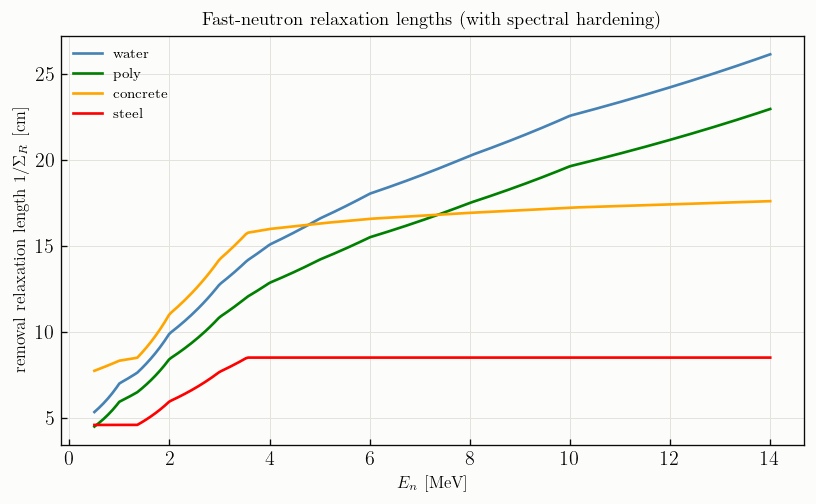

The penetrating flux is the 8-14 MeV Watt tail: in water its relaxation length
doubles, 9.9 cm at 2 MeV -> 20.3 cm at 8 MeV. The 4 m pool is 'only'
~20 hardened relaxation lengths -- a superb shield, but not sufficient alone.


In [2]:
# Attenuation lengths and the hardening that defeats naive estimates.
e_n = np.linspace(0.5, 14, 300)
fig, ax = plt.subplots(figsize=(6.9, 4.3))
for mat, color in (("water", pl.BLUE), ("poly", pl.GREEN),
                   ("concrete", pl.ORANGE), ("steel", pl.RED)):
    ax.plot(e_n, 1.0 / sigma_removal(mat, e_n), color=color, lw=1.6, label=mat)
ax.set_xlabel(r"$E_n$ [MeV]")
ax.set_ylabel(r"removal relaxation length $1/\Sigma_R$ [cm]")
ax.set_title("Fast-neutron relaxation lengths (with spectral hardening)")
ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

print("The penetrating flux is the 8-14 MeV Watt tail: in water its relaxation length")
print(f"doubles, {1/float(sigma_removal('water',[2.0])[0]):.1f} cm at 2 MeV -> "
      f"{1/float(sigma_removal('water',[8.0])[0]):.1f} cm at 8 MeV. The 4 m pool is 'only'")
print("~20 hardened relaxation lengths -- a superb shield, but not sufficient alone.")

## Neutrons: rate into the LS versus package thickness

fissions 3.12e+17/s -> leaking neutrons 1.90e+17/s; fraction headed at the LS 0.031

configuration                   neutrons/day into LS
----------------------------------------------------
pool water only (4.05 m)        2.259e+11           
+ 1 m water-equivalent package  2.757e+09           
+ 3 m water-equivalent          5.963e+05           
+ 6 m water-equivalent          3.020e+00           
+ 2 m steel                     1.358e+01           


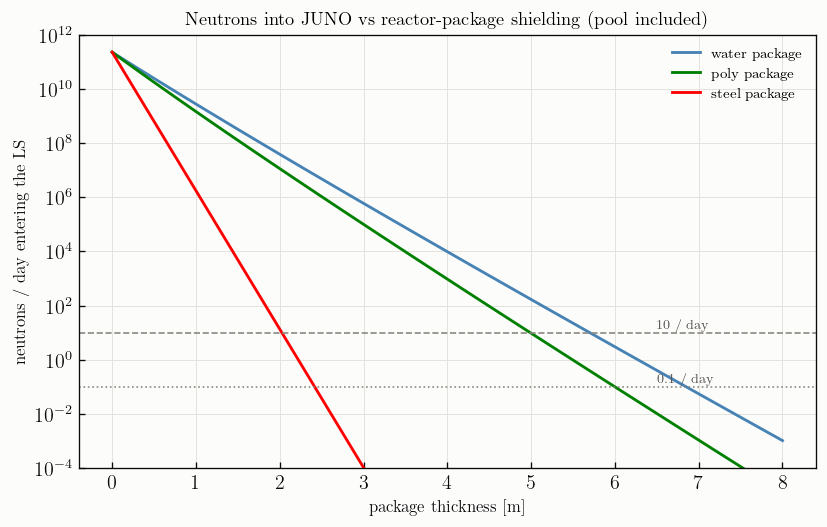

target      water [m]  poly [m]  steel [m]
------------------------------------------
< 10.0/day  5.70       4.99      2.03     
< 0.1/day   6.85       6.00      2.42     


In [3]:
est = ShieldingEstimate()          # 10 MW, 50 m, 25% leakage, buildup x5
print(f"fissions {est.fission_rate:.2e}/s -> leaking neutrons "
      f"{est.neutron_source:.2e}/s; fraction headed at the LS {est.geom:.3f}")
print()
rows = [["pool water only (4.05 m)", est.neutron_rate_per_day([])],
        ["+ 1 m water-equivalent package", est.neutron_rate_per_day([("water", 100)])],
        ["+ 3 m water-equivalent", est.neutron_rate_per_day([("water", 300)])],
        ["+ 6 m water-equivalent", est.neutron_rate_per_day([("water", 600)])],
        ["+ 2 m steel", est.neutron_rate_per_day([("steel", 200)])]]
print(pl.table(rows, ["configuration", "neutrons/day into LS"], floatfmt="{:.3e}"))

d_grid = np.linspace(0, 800, 120)
fig, ax = plt.subplots(figsize=(7.0, 4.5))
for mat, color in (("water", pl.BLUE), ("poly", pl.GREEN), ("steel", pl.RED)):
    rates = [est.neutron_rate_per_day([(mat, d)]) for d in d_grid]
    ax.semilogy(d_grid / 100, rates, color=color, lw=1.7, label=f"{mat} package")
ax.axhline(10, color=pl.INK_MUTED, lw=1.0, ls="--")
ax.axhline(0.1, color=pl.INK_MUTED, lw=1.0, ls=":")
ax.annotate("10 / day", xy=(6.5, 14), fontsize=8, color=pl.INK_SECONDARY)
ax.annotate("0.1 / day", xy=(6.5, 0.14), fontsize=8, color=pl.INK_SECONDARY)
ax.set_ylim(1e-4, 1e12)
ax.set_xlabel("package thickness [m]")
ax.set_ylabel("neutrons / day entering the LS")
ax.set_title("Neutrons into JUNO vs reactor-package shielding (pool included)")
ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

rows = []
for tgt in (10.0, 0.1):
    rows.append([f"< {tgt}/day",
                 est.required_water_equivalent_cm(tgt) / 100,
                 est.required_water_equivalent_cm(tgt, "poly") / 100,
                 est.required_water_equivalent_cm(tgt, "steel") / 100])
print(pl.table(rows, ["target", "water [m]", "poly [m]", "steel [m]"],
               floatfmt="{:.2f}"))

## Direct core gammas: the harder constraint

The $\gamma$ attenuation length in water ($\sim20$–$45$ cm at MeV energies) is far longer
than the neutron removal length, so the pool helps less; the package needs a high-$Z$
layer.

configuration    core gammas/day (>1 MeV) into LS
-------------------------------------------------
pool water only  6.471e+15                       
+ 20 cm lead     3.204e+11                       
+ 40 cm lead     1.751e+07                       
+ 80 cm lead     6.198e-02                       


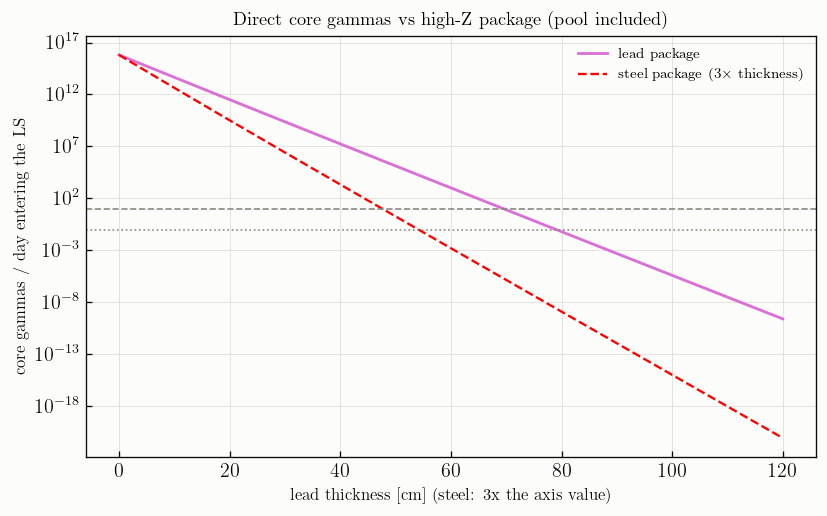

lead for < 10.0/day: 70 cm
lead for < 0.1/day: 79 cm


In [4]:
rows = [["pool water only", est.gamma_rate_per_day([])],
        ["+ 20 cm lead", est.gamma_rate_per_day([("lead", 20)])],
        ["+ 40 cm lead", est.gamma_rate_per_day([("lead", 40)])],
        ["+ 80 cm lead", est.gamma_rate_per_day([("lead", 80)])]]
print(pl.table(rows, ["configuration", "core gammas/day (>1 MeV) into LS"],
               floatfmt="{:.3e}"))

d_pb = np.linspace(0, 120, 100)
fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.semilogy(d_pb, [est.gamma_rate_per_day([("lead", d)]) for d in d_pb],
            color=pl.MAGENTA, lw=1.7, label="lead package")
ax.semilogy(d_pb, [est.gamma_rate_per_day([("steel", 3 * d)]) for d in d_pb],
            color=pl.RED, lw=1.4, ls="--", label=r"steel package ($3\times$ thickness)")
ax.axhline(10, color=pl.INK_MUTED, lw=1.0, ls="--")
ax.axhline(0.1, color=pl.INK_MUTED, lw=1.0, ls=":")
ax.set_xlabel("lead thickness [cm]  (steel: 3x the axis value)")
ax.set_ylabel("core gammas / day entering the LS")
ax.set_title("Direct core gammas vs high-Z package (pool included)")
ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

for tgt in (10.0, 0.1):
    print(f"lead for < {tgt}/day: {est.required_gamma_layer_cm(tgt):.0f} cm")

## How well is the fast-neutron spectrum captured?

Honestly: at *estimate grade*, and the distinction matters. Removal theory attenuates a
"fast group"; it does not transport the spectrum. Three tiers:

1. **Bulk spectral hardening** — captured, and it is the whole game. The penetrating flux
   is the $8$–$14$ MeV Watt tail where relaxation lengths double; treating the spectrum as
   a fission-averaged single group would understate the required steel by a factor
   $\sim6$ (verified below).
2. **Resonance windows** — *not* captured: real transmitted spectra peak at cross-section
   anti-resonances (oxygen near $2.35$ MeV; the famous iron windows at $24$/$82$ keV that
   make steel transparent to intermediate neutrons). Bounded below by a $\times1.5$
   tail-window allowance ($+15\%$ in thickness), and rendered benign by the design's
   hydrogen backing: window neutrons leaking a steel package are moderated and captured in
   the first decimetres of pool water.
3. **The emergent spectrum shape at the LS** — not reliable at all (it would be
   window-peaked, not Watt-like). The requirement metric is built to be immune to this:
   every entering neutron is counted through its $2.2$ MeV capture gamma, regardless of
   its energy.

In [5]:
import reactor.shielding as S

def flat_removal(material, e_mev):
    e = np.atleast_1d(np.asarray(e_mev, float))
    sig = sum(n * S._SIGMA_R[el] * 1e-24
              for el, n in S._COMPOSITIONS[material].items())
    return np.full_like(e, sig)

orig = S.sigma_removal
try:
    S.sigma_removal = flat_removal
    d_flat = ShieldingEstimate().required_water_equivalent_cm(10.0, "steel") / 100
finally:
    S.sigma_removal = orig
d_def = est.required_water_equivalent_cm(10.0, "steel") / 100

orig_np = S._SIG_NP.copy()
try:
    S._SIG_NP = orig_np.copy(); S._SIG_NP[:, 1] = orig_np[:, 1] / 1.5
    d_win = ShieldingEstimate().required_water_equivalent_cm(10.0, "steel") / 100
finally:
    S._SIG_NP = orig_np

rows = [["flat fission-average (no hardening)", d_flat],
        ["default: n-p-scaled hardening", d_def],
        ["tail lambda x1.5 (window allowance)", d_win]]
print(pl.table(rows, ["spectral treatment", "steel for <10 n/day [m]"],
               floatfmt="{:.2f}"))
print()
print("The first-order effect (hardening) changes the answer by a factor ~6 and is in;")
print("the second-order effects (windows) are bounded at ~15% and absorbed by the pool.")
print("A design would settle this with MCNP/Geant4; the metre scale will not move.")

spectral treatment                   steel for <10 n/day [m]
------------------------------------------------------------
flat fission-average (no hardening)  0.36                   
default: n-p-scaled hardening        2.03                   
tail lambda x1.5 (window allowance)  2.32                   

The first-order effect (hardening) changes the answer by a factor ~6 and is in;
the second-order effects (windows) are bounded at ~15% and absorbed by the pool.
A design would settle this with MCNP/Geant4; the metre scale will not move.


## Activation: which isotopes, and what do they emit?

**Shielding / pool water** (fast-threshold reactions -- both need the far Watt tail):

| isotope | channel | threshold | $T_{1/2}$ | emission |
|---|---|---|---|---|
| $^{16}$N | $^{16}$O$(n,p)$ | $10.2$ MeV | $7.1$ s | $\beta^-$ + **6.13 MeV $\gamma$** (69%), 7.12 MeV (5%) |
| $^{17}$N | $^{17}$O$(n,p)$ | $8.0$ MeV | $4.2$ s | $\beta^-$ + **delayed neutron** ($0.4$–$1.2$ MeV, 95%) |
| $^{3}$H | $^{2}$H$(n,\gamma)$ | — | $12.3$ yr | $\beta^-$, $18.6$ keV endpoint (invisible) |

$^{16}$N is the classic reactor-coolant nuisance (6.13 MeV, squarely in our windows) and
$^{17}$N is the subtle one — a *neutron* emitter, able to fake correlated (IBD-like)
signatures, not just singles. Both are governed by the $>8$–$10$ MeV flux and die in
seconds where they are made: they dominate the reactor's **own pit water** (keep its
circulation loop hydraulically separate, with a $\sim$minute delay leg — standard reactor
practice) and are utterly negligible in the JUNO pool, where the entire entering flux is
$\sim10$ n/day by design.

**Rock / concrete / structures** (mostly thermal capture of the moderated leakage):

| isotope | channel | $T_{1/2}$ | emission |
|---|---|---|---|
| $^{24}$Na | $^{23}$Na$(n,\gamma)$, $^{27}$Al$(n,\alpha)$ | $15.0$ h | $\gamma$ **1.369 + 2.754 MeV** cascade |
| $^{56}$Mn | $^{55}$Mn$(n,\gamma)$ | $2.6$ h | $\gamma$ 0.847, 1.811, 2.113 MeV |
| $^{28}$Al | $^{27}$Al$(n,\gamma)$ | $2.2$ min | $\gamma$ 1.779 MeV |
| $^{42}$K | $^{41}$K$(n,\gamma)$ | $12.4$ h | $\gamma$ 1.525 MeV |
| $^{41}$Ar | $^{40}$Ar$(n,\gamma)$, cavern air | $1.8$ h | $\gamma$ 1.294 MeV |
| $^{59}$Fe / $^{54}$Mn / $^{60}$Co | steel + impurities | 44 d / 312 d / **5.3 yr** | $\gamma$ 1.1–1.3 MeV pairs |

JUNO's granite is Na/K/Al-rich, so $^{24}$Na (with its 2.75 MeV line) is the workhorse
concern during operation, plus the *prompt* capture-gamma glow (H 2.2, Si 3.5/4.9,
Fe 7.6 MeV) around the shield. None of it reaches the LS as gammas — line-of-sight
attenuations computed below — so these are radiological and *legacy* concerns: the
long-lived steel activation ($^{60}$Co at 5.3 yr) persists after shutdown, which matters
for the assumption that reactor-off periods return JUNO to pristine astrophysics running
near the pit, and for decommissioning.

In [6]:
e_w = np.linspace(1e-3, 20, 8000)
w_w = watt_spectrum(e_w)
f10 = float(np.trapezoid(w_w[e_w > 10.2], e_w[e_w > 10.2]))
f8 = float(np.trapezoid(w_w[e_w > 8.0], e_w[e_w > 8.0]))
print(f"Watt fraction above 10.2 MeV (16N threshold): {f10:.2e}")
print(f"Watt fraction above  8.0 MeV (17N threshold): {f8:.2e}")
print("-> the activating flux is a per-mille tail of an already-shielded source; in the")
print("   JUNO pool (~10 n/day entering, by design) production is zero for all purposes.")
print()
for label, e_g in (("24Na 2.754 MeV", 2.754), ("56Mn 2.113 MeV", 2.113),
                   ("41Ar 1.294 MeV", 1.294)):
    mu = float(gamma_mu('water', [e_g])[0])
    print(f"{label} gamma through the 4.05 m pool: T = {np.exp(-mu*405):.1e}")
print()
print("Activation gammas born at the pit cannot reach the LS -- the pool alone is 8-11")
print("orders of magnitude, before any rock. The actionable items are operational:")
print("a delay leg on the pit-water loop (16N/17N), ventilation control for 41Ar, and")
print("low-cobalt steel for the package (60Co legacy).")

Watt fraction above 10.2 MeV (16N threshold): 1.10e-03
Watt fraction above  8.0 MeV (17N threshold): 6.08e-03
-> the activating flux is a per-mille tail of an already-shielded source; in the
   JUNO pool (~10 n/day entering, by design) production is zero for all purposes.

24Na 2.754 MeV gamma through the 4.05 m pool: T = 5.0e-08
56Mn 2.113 MeV gamma through the 4.05 m pool: T = 3.7e-09
41Ar 1.294 MeV gamma through the 4.05 m pool: T = 1.3e-11

Activation gammas born at the pit cannot reach the LS -- the pool alone is 8-11
orders of magnitude, before any rock. The actionable items are operational:
a delay leg on the pit-water loop (16N/17N), ventilation control for 41Ar, and
low-cobalt steel for the package (60Co legacy).


## Summary

| requirement | package needed (on top of JUNO's 4 m pool water) |
|---|---|
| neutrons $<10$/day | $\approx5.7$ m water-eq $\;\approx$ $5.0$ m poly $\approx$ $2.0$ m steel |
| neutrons $<0.1$/day | $\approx6.9$ m water-eq $\approx$ $2.4$ m steel |
| core $\gamma$ $<10$/day | $\approx70$ cm lead (or $\approx2$ m steel) |
| core $\gamma$ $<0.1$/day | $\approx80$ cm lead |

**The conclusion is reassuringly conventional**: the reactor needs a
research-reactor-class shield — and that is exactly what every deployable or pool-type
reactor carries anyway. A TRIGA-style installation (core at the bottom of a $6$–$8$ m
water pit, which is the *standard* configuration for MW-class research reactors) meets the
neutron requirement by itself; the gamma requirement adds a sub-metre high-$Z$ collar or
is absorbed into the pit geometry. The physics-driven requirement and the
radiation-protection requirement land within a factor of a few of each other, because both
demand $\sim10^{-11}$-level attenuation.

Numbers worth keeping: unshielded, $2\times10^{11}$ neutrons/day would enter the LS
through the pool alone — the analysis programme of notebooks 5–7 is *entirely contingent*
on the shield; with the standard package, the reactor contributes $\ll0.1$/day against
backgrounds of hundreds/day, i.e. nothing.

For a real design: Monte Carlo transport (streaming through coolant/control penetrations
dominates real leakage), skyshine off the cavern ceiling, rock activation and
capture-gamma fields, and the pool's own capture-gamma budget near the wall — all beyond
this removal-theory estimate, none expected to change the metre-scale answer.